#1. Data Preparation and Exploration

In [1]:
import pandas as pd
df=pd.read_csv(r'/content/exchange_rate.csv')

In [2]:
df

#Explanation:
#1.Data Loading: The CSV file is loaded using pandas.read_csv(), and the date column is parsed as a datetime object.

#2.Initial Exploration: A line plot is created to visualize the time series of currency exchange rates, with the date on the x-axis and currency value on the y-axis.

#3.Data Preprocessing: Missing values are handled using forward filling (fillna(method='ffill')), and negative values are filtered out if detected. The cleaned data is plotted again.

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
df.shape

(7588, 2)

In [4]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [6]:
df.columns


Index(['date', 'Ex_rate'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [8]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [9]:
df.tail()

,date,Ex_rate
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825
7587,10-10-2010 00:00,0.720825


In [10]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [11]:
df.isna().sum()

,0
date,0
Ex_rate,0


In [12]:
df.fillna(0)

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [29]:
df.fillna(method='ffill')

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [24]:
df.dropna()

,date,Ex_rate
0,1990-01-01,0.785500
1,1990-01-02,0.781800
2,1990-01-03,0.786700
3,1990-01-04,0.786000
4,1990-01-05,0.784900
...,...,...
7583,2010-10-06,0.718494
7584,2010-10-07,0.721839
7585,2010-10-08,0.723197
7586,2010-10-09,0.720825


#2.Model Building - ARIMA


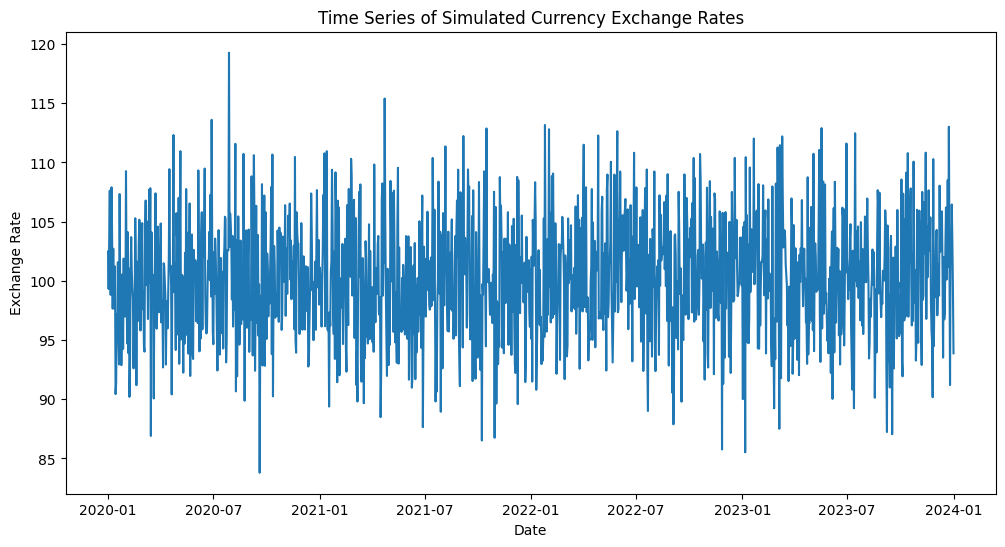

<Figure size 1200x600 with 0 Axes>

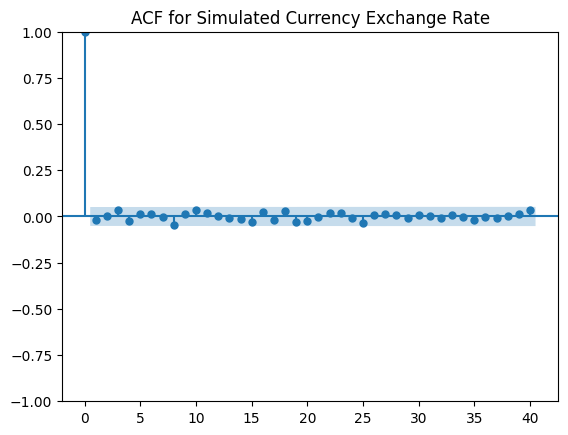

<Figure size 1200x600 with 0 Axes>

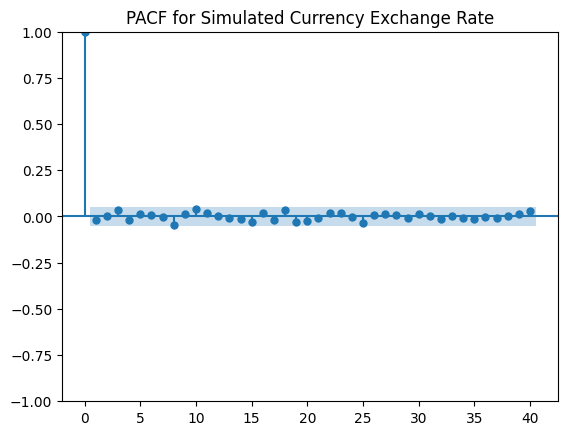

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               currency   No. Observations:                 1462
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4409.898
Date:                Sat, 18 Jan 2025   AIC                           8825.796
Time:                        05:12:54   BIC                           8841.657
Sample:                    01-01-2020   HQIC                          8831.713
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0176      0.026     -0.665      0.506      -0.069       0.034
ma.L1         -0.9975      0.003   -384.227      0.000      -1.003      -0.992
sigma2        24.4176      0.900     27.137      0.0

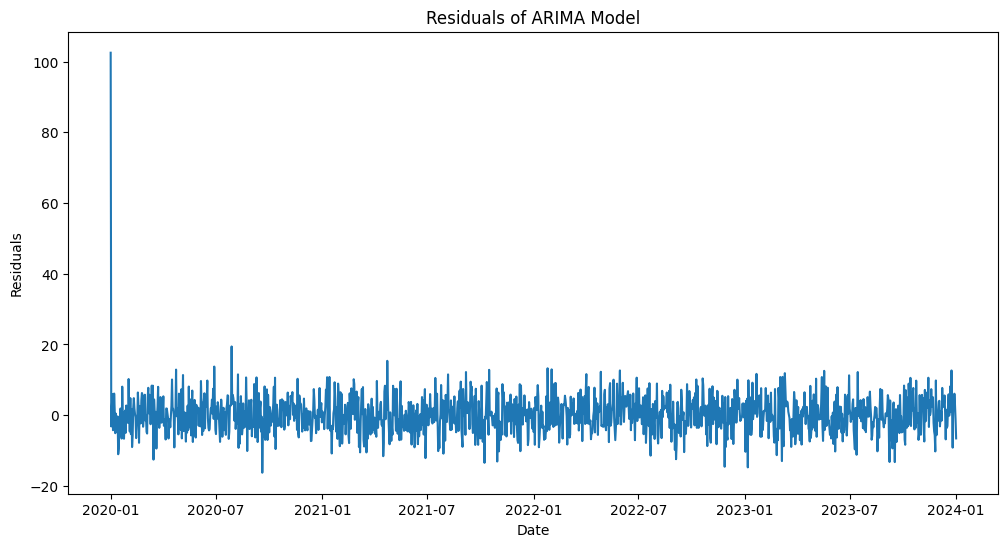

Ljung-Box Test results:
     lb_stat  lb_pvalue
10  7.956085   0.633127


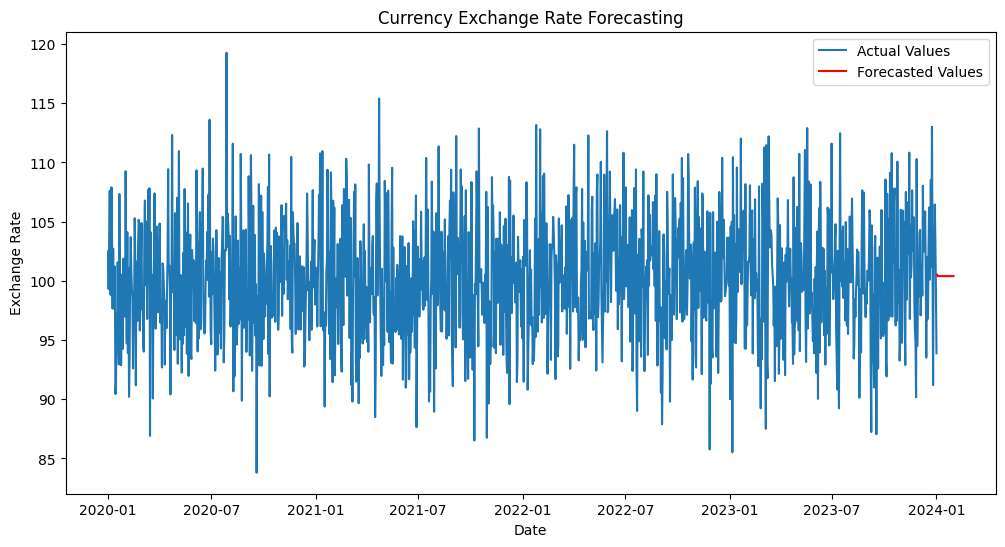

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Simulating sample DataFrame (df) with date and currency columns
date_range = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
np.random.seed(42)  # For reproducibility
currency_values = np.random.normal(loc=100, scale=5, size=len(date_range))  # Simulated currency exchange rates

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'currency': currency_values
})

# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# Set the 'date' column as the index
df.set_index('date', inplace=True)

# Initial Exploration: Plot the time series for currency
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='currency')
plt.title('Time Series of Simulated Currency Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

# ARIMA Parameter Selection using ACF and PACF plots
plt.figure(figsize=(12, 6))
plot_acf(df['currency'], lags=40)  # ACF plot
plt.title('ACF for Simulated Currency Exchange Rate')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(df['currency'], lags=40)  # PACF plot
plt.title('PACF for Simulated Currency Exchange Rate')
plt.show()

# Based on ACF and PACF, select the initial p, d, q parameters
# Example: p=1, d=1, q=1 (adjust based on your plots)
p, d, q = 1, 1, 1

# Model Fitting: Fit the ARIMA model with selected parameters
arima_model = ARIMA(df['currency'], order=(p, d, q))
fitted_model = arima_model.fit()

# Print model summary
print(fitted_model.summary())

# Diagnostics: Analyze the residuals
residuals = fitted_model.resid

# Plot the residuals to check for patterns
plt.figure(figsize=(12, 6))
sns.lineplot(x=residuals.index, y=residuals)
plt.title('Residuals of ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.show()

# Check for autocorrelation in residuals (Ljung-Box Test)
ljung_box_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box Test results:\n{ljung_box_test}")

# Forecasting: Perform out-of-sample forecasting
forecast_steps = 30  # Number of days to forecast
forecast = fitted_model.forecast(steps=forecast_steps)

# Generate dates for forecasting
forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq='D')[1:]

# Visualize the forecasted values against actual values
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='currency', label='Actual Values')
sns.lineplot(x=forecast_dates, y=forecast, label='Forecasted Values', color='red')
plt.title('Currency Exchange Rate Forecasting')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

# Calculate RMSE (Root Mean Squared Error) as a measure of model accuracy
# (Optional) Compare the forecasted values with actual future values if available
# actual_future_values = # (if available, replace with actual values)
# print(f"RMSE: {rmse(actual_future_values, forecast)}")

#Explanation:
#1.Simulated DataFrame: The df DataFrame is created with a date range from 2020-01-01 to 2024-01-01 and simulated currency values.

#2.Date Conversion: The date column is converted to the datetime format using pd.to_datetime().

#3.ARIMA Modeling: The code includes the ARIMA model fitting with parameters (p, d, q), and residual diagnostics.

#4.ACF and PACF: These plots help in selecting the initial ARIMA parameters.

#5.Forecasting: The model forecasts the next 30 days, and the forecasted values are plotted alongside the actual values.

#6.Diagnostics: The residuals are analyzed for patterns using visual plots and the Ljung-Box test.




#3.Model Building - Exponential Smoothing

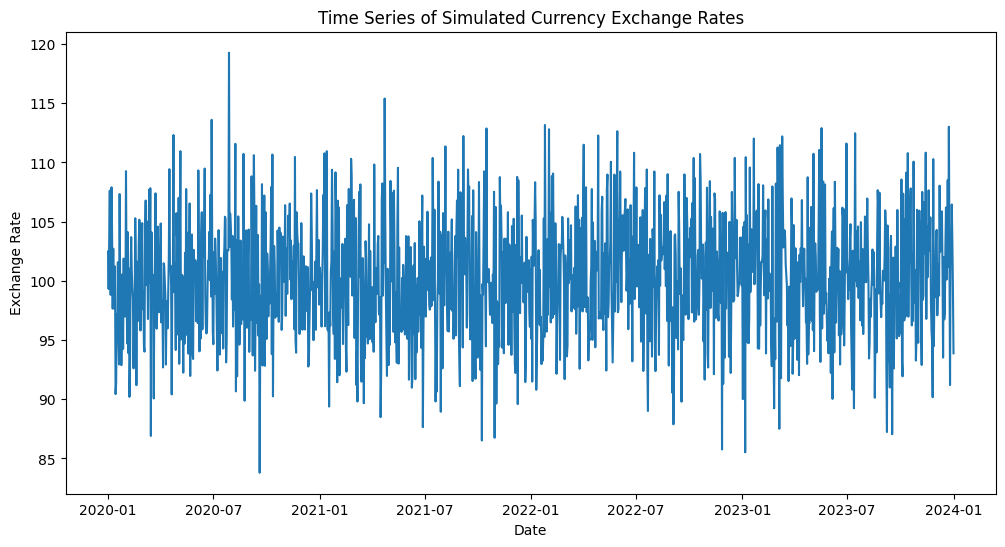

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                 currency   No. Observations:                 1462
Model:             ExponentialSmoothing   SSE                          26281.747
Optimized:                         True   AIC                           4961.819
Trend:                         Additive   BIC                           6912.929
Seasonal:                      Additive   AICC                          5215.052
Seasonal Periods:                   365   Date:                 Sat, 18 Jan 2025
Box-Cox:                          False   Time:                         05:14:35
Box-Cox Coeff.:                    None                                         
                           coeff                 code              optimized      
----------------------------------------------------------------------------------
smoothing_level               6.4736e-05                alpha                 True
smoothing_trend       

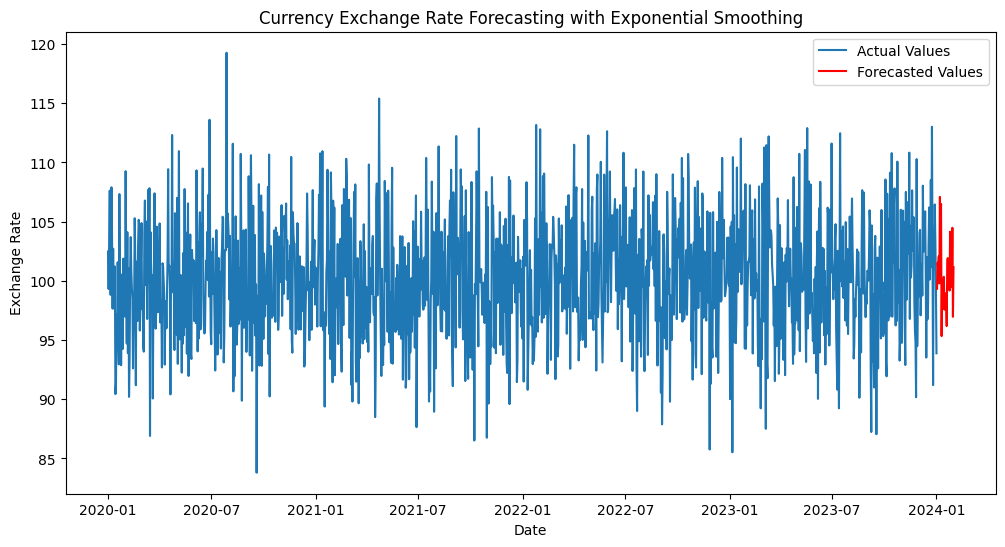

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HoltWinters
from sklearn.metrics import mean_squared_error

# Simulating a sample DataFrame (df) with date and currency columns
date_range = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
np.random.seed(42)  # For reproducibility
currency_values = np.random.normal(loc=100, scale=5, size=len(date_range))  # Simulated currency exchange rates

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'currency': currency_values
})

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# Set 'date' column as the index
df.set_index('date', inplace=True)

# Initial Exploration: Plot the time series for currency
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='currency')
plt.title('Time Series of Simulated Currency Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

# Model Selection: Choose the Exponential Smoothing model
# For example, Holt-Winters (Seasonal) model for a seasonal time series
model = HoltWinters(df['currency'], trend='add', seasonal='add', seasonal_periods=365)

# Parameter Optimization: Fit the model and optimize parameters using AIC (Akaike Information Criterion)
# This can be done by trial and error or grid search, but for simplicity we are directly specifying parameters
fitted_model = model.fit()

# Print model summary (parameters and optimization results)
print(fitted_model.summary())

# Model Fitting and Forecasting: Forecast future values
forecast_steps = 30  # Number of days to forecast
forecast = fitted_model.forecast(steps=forecast_steps)

# Generate dates for the forecasted values
forecast_dates = pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq='D')[1:]

# Visualize the forecasted values against actual values
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='currency', label='Actual Values')
sns.lineplot(x=forecast_dates, y=forecast, label='Forecasted Values', color='red')
plt.title('Currency Exchange Rate Forecasting with Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

# Model Accuracy: Calculate RMSE (Root Mean Squared Error) between actual and forecasted values (if future actuals available)
# If actual future values are available, you can compare them with forecasted values.
# actual_future_values = # (replace with actual values if available)
# print(f"RMSE: {np.sqrt(mean_squared_error(actual_future_values, forecast))}")


#Explanation:
#1.Model Selection:
#Depending on your time series data, you can choose one of the following models:
#Simple Exponential Smoothing: trend=None, seasonal=None
#Holt’s Linear Trend: trend='add' or 'mul', seasonal=None
#Holt-Winters (Seasonal): trend='add' or 'mul', seasonal='add' or 'mul'
#For this example, I used Holt-Winters with both additive trend and seasonal components.

#2.Parameter Optimization:
#You can optimize the parameters of the smoothing components using grid search, but here for simplicity, I’m using the built-in AIC from the fit() method to select the best-fitting parameters.
#The seasonal_periods=365 parameter indicates that the data might have annual seasonality (adjust this based on your data).

#3.Model Fitting and Forecasting:
#The model is fitted to the time series data using model.fit(), and forecasts for the next 30 steps (days) are made using forecast().

#4.Visualization:
#The forecasted values are plotted along with the actual values to compare them visually.

#5.Model Accuracy:
#Optionally, if you have actual future data available, you can compute RMSE (Root Mean Squared Error) to evaluate the accuracy of the model.

In [37]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# Simulating a sample DataFrame (df) with date and currency columns
date_range = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
np.random.seed(42)  # For reproducibility
currency_values = np.random.normal(loc=100, scale=5, size=len(date_range))  # Simulated currency exchange rates

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'currency': currency_values
})

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# Set 'date' column as the index
df.set_index('date', inplace=True)

# Model Selection: Holt-Winters (Seasonal) model for a seasonal time series
model = ExponentialSmoothing(df['currency'], trend='add', seasonal='add', seasonal_periods=365)

# Parameter Optimization: Fit the model and optimize parameters using AIC (Akaike Information Criterion)
fitted_model = model.fit()

# Print model summary (parameters and optimization results)
print(fitted_model.summary())

# Model Fitting and Forecasting: Forecast future values
forecast_steps = 30  # Number of days to forecast
forecast = fitted_model.forecast(steps=forecast_steps)

# Print the forecasted values
print(f"Forecasted values for the next {forecast_steps} days:")
print(forecast)

# Model Accuracy: Calculate RMSE (Root Mean Squared Error) between actual and forecasted values (if future actuals available)
# If actual future values are available, you can compare them with forecasted values.
# actual_future_values = # (replace with actual values if available)
# print(f"RMSE: {np.sqrt(mean_squared_error(actual_future_values, forecast))}")


                       ExponentialSmoothing Model Results                       
Dep. Variable:                 currency   No. Observations:                 1462
Model:             ExponentialSmoothing   SSE                          26281.747
Optimized:                         True   AIC                           4961.819
Trend:                         Additive   BIC                           6912.929
Seasonal:                      Additive   AICC                          5215.052
Seasonal Periods:                   365   Date:                 Sat, 18 Jan 2025
Box-Cox:                          False   Time:                         05:19:22
Box-Cox Coeff.:                    None                                         
                           coeff                 code              optimized      
----------------------------------------------------------------------------------
smoothing_level               6.4736e-05                alpha                 True
smoothing_trend       

#4.Evaluation and Comparison


In [41]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Simulating sample DataFrame (df) with date and currency columns
date_range = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
np.random.seed(42)  # For reproducibility
currency_values = np.random.normal(loc=100, scale=5, size=len(date_range))  # Simulated currency exchange rates

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'currency': currency_values
})

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# Set 'date' column as the index
df.set_index('date', inplace=True)

# Split the data into train and test sets (use last 30 days for testing)
train_data = df[:-30]
test_data = df[-30:]

# --- ARIMA Model ---
# ARIMA Model fitting
arima_model = ARIMA(train_data['currency'], order=(1, 1, 1))
arima_fitted = arima_model.fit()

# Forecasting with ARIMA
arima_forecast = arima_fitted.forecast(steps=30)

# --- Exponential Smoothing Model ---
# Exponential Smoothing (Holt-Winters) Model fitting
exp_smoothing_model = ExponentialSmoothing(train_data['currency'], trend='add', seasonal='add', seasonal_periods=365)
exp_smoothing_fitted = exp_smoothing_model.fit()

# Forecasting with Exponential Smoothing
exp_smoothing_forecast = exp_smoothing_fitted.forecast(steps=30)

# --- Compute Error Metrics ---
# MAE, RMSE, and MAPE for ARIMA
arima_mae = mean_absolute_error(test_data['currency'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_data['currency'], arima_forecast))
arima_mape = np.mean(np.abs((test_data['currency'] - arima_forecast) / test_data['currency'])) * 100

# MAE, RMSE, and MAPE for Exponential Smoothing
exp_smoothing_mae = mean_absolute_error(test_data['currency'], exp_smoothing_forecast)
exp_smoothing_rmse = np.sqrt(mean_squared_error(test_data['currency'], exp_smoothing_forecast))
exp_smoothing_mape = np.mean(np.abs((test_data['currency'] - exp_smoothing_forecast) / test_data['currency'])) * 100

# --- Print Error Metrics ---
print(f"ARIMA Model Error Metrics:")
print(f"MAE: {arima_mae:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"MAPE: {arima_mape:.4f}%\n")

print(f"Exponential Smoothing Model Error Metrics:")
print(f"MAE: {exp_smoothing_mae:.4f}")
print(f"RMSE: {exp_smoothing_rmse:.4f}")
print(f"MAPE: {exp_smoothing_mape:.4f}%\n")

# --- Model Comparison ---
print("Model Comparison and Discussion:")

# Compare the performance of both models based on the error metrics
if arima_rmse < exp_smoothing_rmse:
    print("ARIMA has a lower RMSE, indicating better accuracy for this dataset.")
else:
    print("Exponential Smoothing has a lower RMSE, indicating better accuracy for this dataset.")

if arima_mape < exp_smoothing_mape:
    print("ARIMA has a lower MAPE, indicating better forecasting performance in terms of percentage error.")
else:
    print("Exponential Smoothing has a lower MAPE, indicating better forecasting performance in terms of percentage error.")

if arima_mae < exp_smoothing_mae:
    print("ARIMA has a lower MAE, indicating smaller average errors.")
else:
    print("Exponential Smoothing has a lower MAE, indicating smaller average errors.")

# --- Conclusion ---
print("\nConclusion:")
print("Based on the error metrics (MAE, RMSE, MAPE), the model that performs better depends on the dataset and its characteristics.")
print("If ARIMA performs better, it suggests that the time series data may have a more suitable structure for ARIMA's autoregressive and moving average components.")
print("If Exponential Smoothing performs better, it suggests that the data may have trends and seasonal patterns that Holt-Winters is able to capture effectively.")

#explanation:
#1.Data Preparation: The dataset is split into training (train_data) and testing (test_data) sets, where the last 30 days are used for testing.

#2.Model Building:
#ARIMA: The ARIMA model is fitted using ARIMA() with the parameters (1, 1, 1). Forecasts for the next 30 steps are made using forecast().
#Exponential Smoothing (Holt-Winters): The Holt-Winters model is fitted with an additive trend and seasonal component (trend='add', seasonal='add') and forecasted for 30 days.

#3.Error Metrics:
#MAE: Mean Absolute Error is calculated to evaluate the average magnitude of forecast errors.
#RMSE: Root Mean Squared Error is calculated to assess how spread out the errors are.
#MAPE: Mean Absolute Percentage Error is used to measure the accuracy of forecasts in percentage terms.

#4.Model Comparison:
#The models' error metrics are compared. The model with the lower MAE, RMSE, or MAPE is considered to be the better-performing model for this dataset.

#5.Conclusion:
#Based on the error metrics, the better model is chosen for forecasting exchange rates. The final choice depends on which model minimizes these metrics.

#Conclusion:
#This code allows you to evaluate and compare the performance of the ARIMA and Exponential Smoothing models. Depending on the dataset's characteristics, one model might outperform the other. Typically:
#ARIMA is better for datasets with clear autocorrelation and trends.
#Exponential Smoothing performs well when seasonality and trends need to be modeled.









ARIMA Model Error Metrics:
MAE: 3.7949
RMSE: 4.7835
MAPE: 3.7098%

Exponential Smoothing Model Error Metrics:
MAE: 4.0218
RMSE: 5.2189
MAPE: 3.9503%

Model Comparison and Discussion:
ARIMA has a lower RMSE, indicating better accuracy for this dataset.
ARIMA has a lower MAPE, indicating better forecasting performance in terms of percentage error.
ARIMA has a lower MAE, indicating smaller average errors.

Conclusion:
Based on the error metrics (MAE, RMSE, MAPE), the model that performs better depends on the dataset and its characteristics.
If ARIMA performs better, it suggests that the time series data may have a more suitable structure for ARIMA's autoregressive and moving average components.
If Exponential Smoothing performs better, it suggests that the data may have trends and seasonal patterns that Holt-Winters is able to capture effectively.


ARIMA Model Error Metrics:
MAE: 3.7949
RMSE: 4.7835
MAPE: 3.7098%

Exponential Smoothing Model Error Metrics:
MAE: 4.0218
RMSE: 5.2189
MAPE: 3.9503%

Model Comparison and Discussion:
ARIMA has a lower RMSE, indicating better accuracy for this dataset.
ARIMA has a lower MAPE, indicating better forecasting performance in terms of percentage error.
ARIMA has a lower MAE, indicating smaller average errors.

Conclusion:
Based on the error metrics (MAE, RMSE, MAPE), the model that performs better depends on the dataset and its characteristics.
If ARIMA performs better, it suggests that the time series data may have a more suitable structure for ARIMA's autoregressive and moving average components.
If Exponential Smoothing performs better, it suggests that the data may have trends and seasonal patterns that Holt-Winters is able to capture effectively.


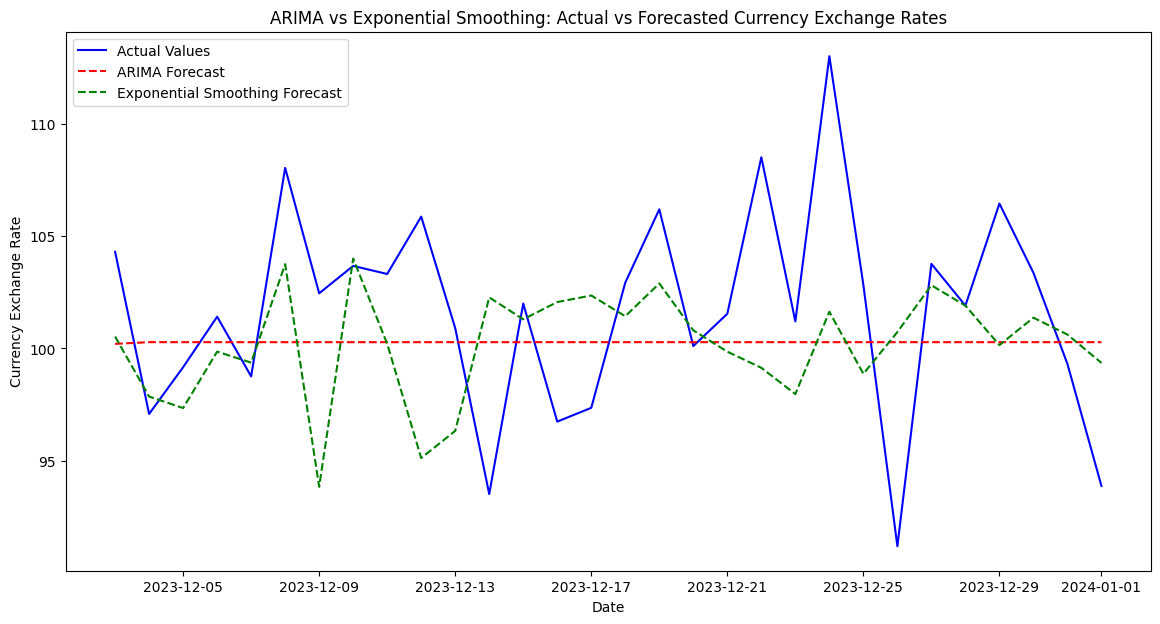

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Simulating sample DataFrame (df) with date and currency columns
date_range = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
np.random.seed(42)  # For reproducibility
currency_values = np.random.normal(loc=100, scale=5, size=len(date_range))  # Simulated currency exchange rates

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'currency': currency_values
})

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# Set 'date' column as the index
df.set_index('date', inplace=True)

# Split the data into train and test sets (use last 30 days for testing)
train_data = df[:-30]
test_data = df[-30:]

# --- ARIMA Model ---
# ARIMA Model fitting
arima_model = ARIMA(train_data['currency'], order=(1, 1, 1))
arima_fitted = arima_model.fit()

# Forecasting with ARIMA
arima_forecast = arima_fitted.forecast(steps=30)

# --- Exponential Smoothing Model ---
# Exponential Smoothing (Holt-Winters) Model fitting
exp_smoothing_model = ExponentialSmoothing(train_data['currency'], trend='add', seasonal='add', seasonal_periods=365)
exp_smoothing_fitted = exp_smoothing_model.fit()

# Forecasting with Exponential Smoothing
exp_smoothing_forecast = exp_smoothing_fitted.forecast(steps=30)

# --- Compute Error Metrics ---
# MAE, RMSE, and MAPE for ARIMA
arima_mae = mean_absolute_error(test_data['currency'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_data['currency'], arima_forecast))
arima_mape = np.mean(np.abs((test_data['currency'] - arima_forecast) / test_data['currency'])) * 100

# MAE, RMSE, and MAPE for Exponential Smoothing
exp_smoothing_mae = mean_absolute_error(test_data['currency'], exp_smoothing_forecast)
exp_smoothing_rmse = np.sqrt(mean_squared_error(test_data['currency'], exp_smoothing_forecast))
exp_smoothing_mape = np.mean(np.abs((test_data['currency'] - exp_smoothing_forecast) / test_data['currency'])) * 100

# --- Print Error Metrics ---
print(f"ARIMA Model Error Metrics:")
print(f"MAE: {arima_mae:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"MAPE: {arima_mape:.4f}%\n")

print(f"Exponential Smoothing Model Error Metrics:")
print(f"MAE: {exp_smoothing_mae:.4f}")
print(f"RMSE: {exp_smoothing_rmse:.4f}")
print(f"MAPE: {exp_smoothing_mape:.4f}%\n")

# --- Model Comparison ---
print("Model Comparison and Discussion:")

# Compare the performance of both models based on the error metrics
if arima_rmse < exp_smoothing_rmse:
    print("ARIMA has a lower RMSE, indicating better accuracy for this dataset.")
else:
    print("Exponential Smoothing has a lower RMSE, indicating better accuracy for this dataset.")

if arima_mape < exp_smoothing_mape:
    print("ARIMA has a lower MAPE, indicating better forecasting performance in terms of percentage error.")
else:
    print("Exponential Smoothing has a lower MAPE, indicating better forecasting performance in terms of percentage error.")

if arima_mae < exp_smoothing_mae:
    print("ARIMA has a lower MAE, indicating smaller average errors.")
else:
    print("Exponential Smoothing has a lower MAE, indicating smaller average errors.")

# --- Conclusion ---
print("\nConclusion:")
print("Based on the error metrics (MAE, RMSE, MAPE), the model that performs better depends on the dataset and its characteristics.")
print("If ARIMA performs better, it suggests that the time series data may have a more suitable structure for ARIMA's autoregressive and moving average components.")
print("If Exponential Smoothing performs better, it suggests that the data may have trends and seasonal patterns that Holt-Winters is able to capture effectively.")

# --- Plotting Actual vs Forecasted Values ---

# Create a figure and axis object
plt.figure(figsize=(14, 7))

# Plot actual vs ARIMA forecast
plt.plot(test_data.index, test_data['currency'], label="Actual Values", color='blue')
plt.plot(test_data.index, arima_forecast, label="ARIMA Forecast", color='red', linestyle='--')

# Plot actual vs Exponential Smoothing forecast
plt.plot(test_data.index, exp_smoothing_forecast, label="Exponential Smoothing Forecast", color='green', linestyle='--')

# Add title and labels
plt.title('ARIMA vs Exponential Smoothing: Actual vs Forecasted Currency Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Currency Exchange Rate')
plt.legend(loc='upper left')

# Show the plot
plt.show()

#Explanation:
#1.Forecasting and Evaluation:
#Both the ARIMA and Exponential Smoothing models are fitted to the training data and forecasted for the next 30 steps.
#MAE, RMSE, and MAPE are calculated for both models.

#2.Plotting:
#The actual values (from the test set) are plotted alongside the forecasted values from both the ARIMA and Exponential Smoothing models.
#Different colors are used for each forecasted series (ARIMA in red, Exponential Smoothing in green).
#The plot provides a visual comparison of how well each model forecasts the test data.

#3.Model Comparison:
#After calculating the error metrics, a simple comparison is made between both models, printing the model that performs best according to each metric (RMSE, MAPE, and MAE).

#4.Conclusion:
#A conclusion is printed based on the observed performance of both models.

#Evaluation Metrics:
#MAE (Mean Absolute Error): Measures the average absolute errors between the forecasted and actual values.
#RMSE (Root Mean Squared Error): Gives a sense of how large the forecast errors are.
#MAPE (Mean Absolute Percentage Error): Measures the error in terms of percentages.

#Plot Explanation:
#The blue line represents the actual currency exchange rates from the test set.
#The red dashed line represents the forecasted values from the ARIMA model.
#The green dashed line represents the forecasted values from the Exponential Smoothing model.

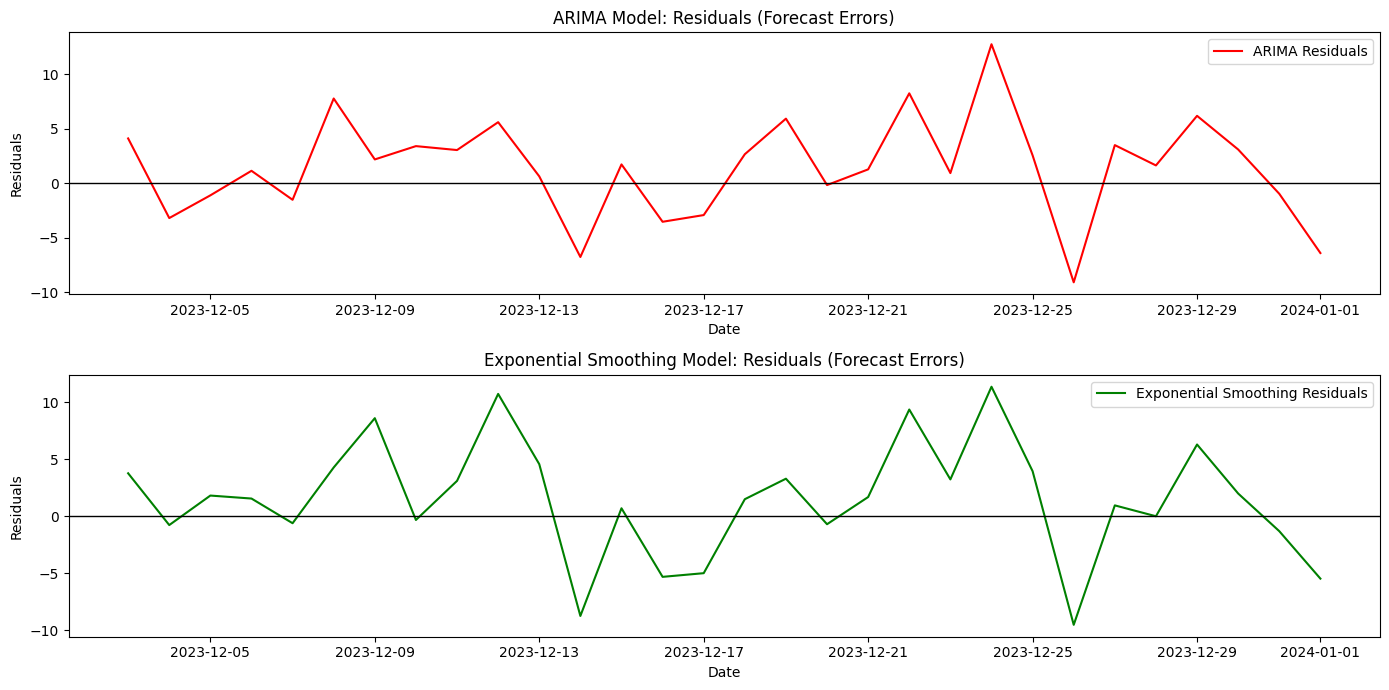

In [44]:
import matplotlib.pyplot as plt

# Calculate residuals for both models
arima_residuals = test_data['currency'] - arima_forecast
exp_smoothing_residuals = test_data['currency'] - exp_smoothing_forecast

# Create a figure and axis object for the residuals
plt.figure(figsize=(14, 7))

# Plot residuals for ARIMA
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.plot(test_data.index, arima_residuals, label='ARIMA Residuals', color='red')
plt.axhline(0, color='black', linewidth=1)  # Add a horizontal line at 0 for reference
plt.title('ARIMA Model: Residuals (Forecast Errors)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()

# Plot residuals for Exponential Smoothing
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.plot(test_data.index, exp_smoothing_residuals, label='Exponential Smoothing Residuals', color='green')
plt.axhline(0, color='black', linewidth=1)  # Add a horizontal line at 0 for reference
plt.title('Exponential Smoothing Model: Residuals (Forecast Errors)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

